에폭당 랜덤 쌍 2만개씩 사용 + GPU 1번 사용

In [1]:
import torch
import torch.nn as nn

class ResBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, 1, 1), 
            nn.BatchNorm2d(out_channels), 
            nn.SiLU(), 
            nn.Conv2d(out_channels, out_channels, 3, 1, 1), 
            nn.BatchNorm2d(out_channels)
            )
        
        self.shortcut = nn.Conv2d(in_channels, out_channels, 1) if in_channels != out_channels else nn.Identity()
        self.silu = nn.SiLU()
    def forward(self, x): return self.silu(self.block(x) + self.shortcut(x))

class EncoderSuperDeep(nn.Module):
    def __init__(self, in_channels=3, base_channels=128, latent_channels=1):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(in_channels, base_channels, 3, 1, 1), 
            ResBlock(base_channels, base_channels), 
            nn.Conv2d(base_channels, base_channels*2, 3, 2, 1), 
            ResBlock(base_channels*2, base_channels*2), 
            nn.Conv2d(base_channels*2, base_channels*4, 3, 2, 1), 
            ResBlock(base_channels*4, base_channels*4), 
            nn.Conv2d(base_channels*4, base_channels*8, 3, 2, 1), 
            ResBlock(base_channels*8, base_channels*8), 
            nn.Conv2d(base_channels*8, base_channels*16, 3, 2, 1), 
            ResBlock(base_channels*16, base_channels*16), 
            nn.Conv2d(base_channels*16, 2 * latent_channels, 3, 1, 1)
            )
        
    def forward(self, x):
        x = self.encoder(x)
        mu, log_var = torch.chunk(x, 2, dim=1)
        return mu, log_var

class DecoderSuperDeep(nn.Module):
    def __init__(self, out_channels=3, base_channels=128, latent_channels=1):
        super().__init__()
        self.decoder = nn.Sequential(
            nn.Conv2d(latent_channels, base_channels*16, 3, 1, 1),
            ResBlock(base_channels*16, base_channels*16), nn.Upsample(scale_factor=2, mode='nearest'), 
            nn.Conv2d(base_channels*16, base_channels*8, 3, 1, 1), 
            ResBlock(base_channels*8, base_channels*8), nn.Upsample(scale_factor=2, mode='nearest'), 
            nn.Conv2d(base_channels*8, base_channels*4, 3, 1, 1), 
            ResBlock(base_channels*4, base_channels*4), 
            nn.Upsample(scale_factor=2, mode='nearest'), 
            nn.Conv2d(base_channels*4, base_channels*2, 3, 1, 1), 
            ResBlock(base_channels*2, base_channels*2), 
            nn.Upsample(scale_factor=2, mode='nearest'), 
            nn.Conv2d(base_channels*2, base_channels, 3, 1, 1), 
            ResBlock(base_channels, base_channels), 
            nn.Conv2d(base_channels, out_channels, 3, 1, 1), 
            nn.Tanh()
            )

    def forward(self, z): return self.decoder(z)

import torch
import torch.nn as nn

class InterpolationNet(nn.Module):
    """
    두 잠재 벡터와 보간 계수(alpha)를 입력받아, 
    학습된 매니폴드 위를 따라가는 새로운 잠재 벡터를 출력하는 네트워크.
    """
    def __init__(self, latent_dim=256, hidden_dim=1024):
    # hidden_dim의 기본값을 1024 -> 512로 수정
    # def __init__(self, latent_dim=256, hidden_dim=512):
        super().__init__()
        
        # 입력 차원: z_A(256) + z_B(256) + alpha(1) = 513
        input_dim = latent_dim * 2 + 1
        
        self.network = nn.Sequential(
            # 입력층: 입력을 받아 더 넓은 차원으로 확장하여 특징 상호작용을 학습할 공간을 제공
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim), # 각 레이어 입력 분포를 정규화하여 학습 안정화
            nn.LeakyReLU(0.2, inplace=True), # ReLU의 단점을 보완한 활성화 함수

            # 은닉층 1: 충분한 용량으로 복잡한 비선형 관계 학습
            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.LeakyReLU(0.2, inplace=True),

            # 은닉층 2: 학습된 특징을 점진적으로 요약하여 출력 차원으로 매핑 준비
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.BatchNorm1d(hidden_dim // 2),
            nn.LeakyReLU(0.2, inplace=True),

            # 출력층: 최종 잠재 벡터 차원으로 매핑. 활성화 함수 없음 (잠재 공간은 비제한적)
            nn.Linear(hidden_dim // 2, latent_dim)
        )

    def forward(self, z_a, z_b, alpha):
        # 입력으로 받은 3개의 텐서를 하나로 이어붙임
        # z_a, z_b: [Batch, 256], alpha: [Batch, 1]
        net_input = torch.cat([z_a, z_b, alpha], dim=1)
        return self.network(net_input)
    
from torch.utils.data import Dataset

class InterpolationDataset(Dataset):
    """
    사전 추출된 잠재 벡터 풀에서 무작위로 두 개의 벡터를 샘플링하고,
    무작위 alpha 값을 생성하여 학습 데이터를 구성하는 데이터셋.
    """
    def __init__(self, latent_vectors_path, num_samples):
        # 미리 추출하여 저장해 둔 실제 잠재 벡터(.pt 파일)를 불러옴 # GPU 텐서를 불러온 뒤, 즉시 CPU 메모리로 이동
        self.latent_vectors = torch.load(latent_vectors_path).to('cpu')
        self.num_latents = len(self.latent_vectors)
        self.num_samples = num_samples

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        # 무작위로 두 잠재 벡터 선택
        idx1, idx2 = torch.randperm(self.num_latents)[:2]
        z_a = self.latent_vectors[idx1]
        z_b = self.latent_vectors[idx2]
        
        # 무작위로 alpha 값 생성
        alpha = torch.rand(1)
        
        return z_a, z_b, alpha
    

In [2]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

# --- 1. 기본 설정 및 경로 ---
print("Step 1: 기본 설정 로드")
DEVICE = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")
# VAE 체크포인트 경로
AE_CHECKPOINT_DIR = '/home/nas/data/YMG/superdeep_ae/checkpoints/'
ENCODER_PATH = os.path.join(AE_CHECKPOINT_DIR, 'encoder_superdeep_best.pth')
DECODER_PATH = os.path.join(AE_CHECKPOINT_DIR, 'decoder_superdeep_best.pth')
# 사전 추출된 잠재 벡터 경로
LATENT_VECTORS_PATH = '/home/nas/data/YMG/superdeep_ae/my_checkpoints/real_latent_vectors_20k.pt'
# 학습된 보간 네트워크를 저장할 경로
OUTPUT_DIR = '/home/nas/data/YMG/superdeep_ae/light_interpolation_network/'
os.makedirs(OUTPUT_DIR, exist_ok=True)
CHECKPOINT_PATH = os.path.join(OUTPUT_DIR, 'interpolation_net_best.pth')


# --- 하이퍼파라미터 ---
LATENT_DIM = 256
HIDDEN_DIM = 1024
BATCH_SIZE = 256
EPOCHS = 100
LR = 1e-4
SAMPLES_PER_EPOCH = 20000 # 한 에포크당 2만 개의 새로운 랜덤 쌍으로 학습 -------------------------


# --- 2. 모델 로드 및 설정 ---
print("Step 2: 모델 로드 및 설정")
# VAE 모델 (Encoder, Decoder) 로드 -> 가중치 동결
# (EncoderSuperDeep, DecoderSuperDeep 클래스 정의가 이 코드 위에 있어야 함)
encoder = EncoderSuperDeep().to(DEVICE)
decoder = DecoderSuperDeep().to(DEVICE)
encoder.load_state_dict(torch.load(ENCODER_PATH, map_location=DEVICE))
decoder.load_state_dict(torch.load(DECODER_PATH, map_location=DEVICE))
encoder.eval() # 평가 모드로 설정
decoder.eval() # 평가 모드로 설정
for param in encoder.parameters(): param.requires_grad = False # VAE 가중치 동결
for param in decoder.parameters(): param.requires_grad = False # VAE 가중치 동결
print("VAE 모델을 로드하고 가중치를 동결했습니다.")

# 보간 네트워크 모델 및 옵티마이저 초기화
interpolation_net = InterpolationNet(latent_dim=LATENT_DIM, hidden_dim=HIDDEN_DIM).to(DEVICE)
optimizer = optim.Adam(interpolation_net.parameters(), lr=LR)
print("보간 네트워크를 초기화했습니다.")


# --- 3. 데이터 로더 준비 ---
print("Step 3: 데이터 로더 준비")
train_dataset = InterpolationDataset(latent_vectors_path=LATENT_VECTORS_PATH, num_samples=SAMPLES_PER_EPOCH)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)


# --- 4. 학습 루프 ---
print("Step 4: 학습 시작")
best_loss = float('inf')
for epoch in range(EPOCHS):
    interpolation_net.train() # 학습 모드로 설정
    total_loss = 0
    
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}")
    for z_a, z_b, alpha in pbar:
        z_a, z_b, alpha = z_a.to(DEVICE), z_b.to(DEVICE), alpha.to(DEVICE)
        
        # 순전파
        optimizer.zero_grad()
        z_interp = interpolation_net(z_a, z_b, alpha)
        
        # 재투영
        # 디코더/인코더는 4D 텐서(B, C, H, W)를 입력받으므로 모양 변경 필요
        z_interp_reshaped = z_interp.view(-1, 1, 16, 16)
        with torch.no_grad(): # VAE는 그래디언트 계산 불필요
            reconstructed_images = decoder(z_interp_reshaped)
            z_hat_interp_reshaped, _ = encoder(reconstructed_images)
        z_hat_interp = z_hat_interp_reshaped.view(-1, LATENT_DIM) # 다시 2D 텐서로 변경
        
        # 손실 계산
        loss = nn.functional.mse_loss(z_interp, z_hat_interp)
        
        # 역전파
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        pbar.set_postfix({"Re-projection Loss": f"{loss.item():.6f}"})
        
    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1} 완료 | Avg Loss: {avg_loss:.6f}")

    # 체크포인트 저장
    if avg_loss < best_loss:
        best_loss = avg_loss
        torch.save(interpolation_net.state_dict(), CHECKPOINT_PATH)
        print(f"New best model found! Loss: {best_loss:.6f}. Checkpoint saved.")

print("\n학습이 모두 완료되었습니다.")

Step 1: 기본 설정 로드
Step 2: 모델 로드 및 설정


/tmp/ipykernel_3529438/3843584847.py:38: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  encoder.load_state_dict(torch.load(ENCODER_PATH, map_location=DEVICE))
/tmp/ipykernel_

VAE 모델을 로드하고 가중치를 동결했습니다.
보간 네트워크를 초기화했습니다.
Step 3: 데이터 로더 준비


/tmp/ipykernel_3529438/1450345007.py:114: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.latent_vectors = torch.load(latent_vectors_path).to('cpu')


Step 4: 학습 시작


...

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7f0d0c9083a0>
Traceback (most recent call last):
  File "/home/a202192022/anaconda3/envs/GM-env/lib/python3.9/site-packages/torch/utils/data/dataloader.py", line 1604, in __del__
    self._shutdown_workers()
  File "/home/a202192022/anaconda3/envs/GM-env/lib/python3.9/site-packages/torch/utils/data/dataloader.py", line 1587, in _shutdown_workers
    if w.is_alive():
  File "/home/a202192022/anaconda3/envs/GM-env/lib/python3.9/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7f0d0c9083a0>
Traceback (most recent call last):
  File "/home/a202192022/anaconda3/envs/GM-env/lib/python3.9/site-packages/torch/utils/data/dataloader.py", line 1604, in __del__
    self._shutdown_workers()
  File "/home/a202192022/anaconda3/en

Epoch 99 완료 | Avg Loss: 0.000621


Epoch 100/100:   0%|          | 0/79 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7f0d0c9083a0>
Traceback (most recent call last):
  File "/home/a202192022/anaconda3/envs/GM-env/lib/python3.9/site-packages/torch/utils/data/dataloader.py", line 1604, in __del__
    self._shutdown_workers()
  File "/home/a202192022/anaconda3/envs/GM-env/lib/python3.9/site-packages/torch/utils/data/dataloader.py", line 1587, in _shutdown_workers
    if w.is_alive():
  File "/home/a202192022/anaconda3/envs/GM-env/lib/python3.9/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7f0d0c9083a0>
Traceback (most recent call last):
  File "/home/a202192022/anaconda3/envs/GM-env/lib/python3.9/site-packages/torch/utils/data/dataloader.py", line 1604, in __del__
    self._shutdown_workers()
  File "/home/a202192022/anaconda3/en

Epoch 100 완료 | Avg Loss: 0.000669

학습이 모두 완료되었습니다.


/tmp/ipykernel_3529438/1953098281.py:73: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  encoder.load_state_dict(torch.load(ENCODER_PATH, map_location=DEVICE))
/tmp/ipykernel_

모든 모델(VAE, 보간 네트워크)을 성공적으로 로드했습니다.

--- Test Pair #1 ---


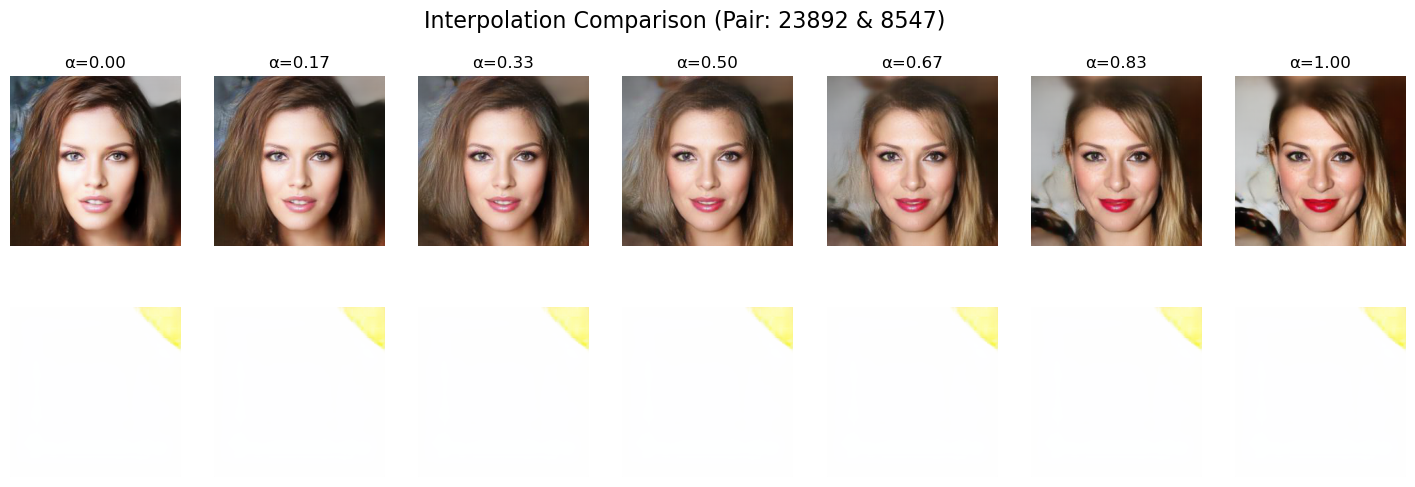


--- Test Pair #2 ---


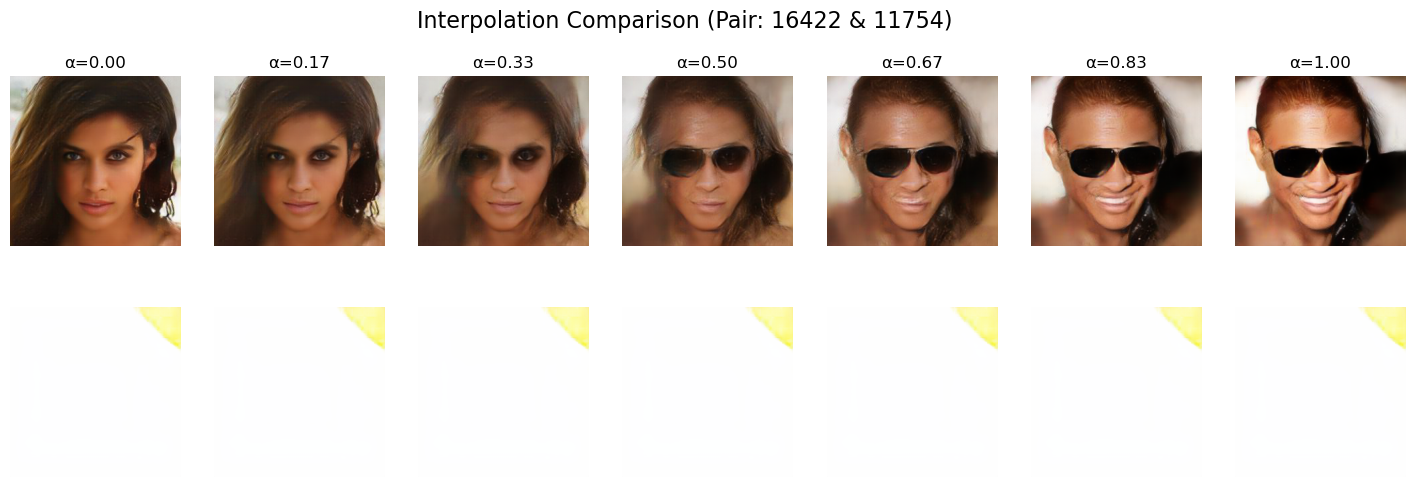


--- Test Pair #3 ---


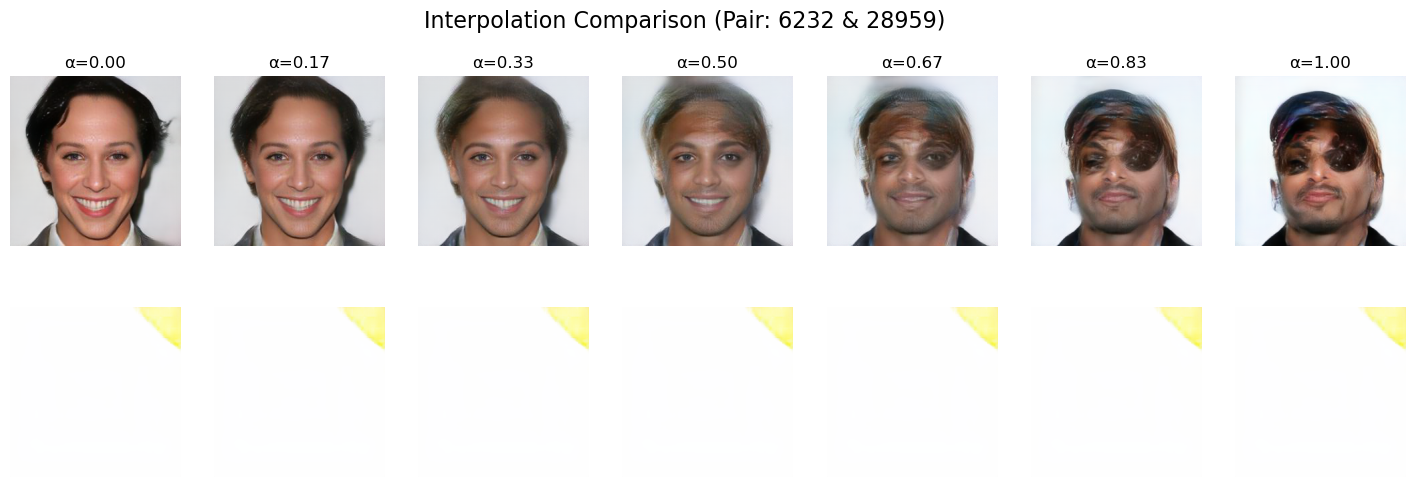


--- Test Pair #4 ---


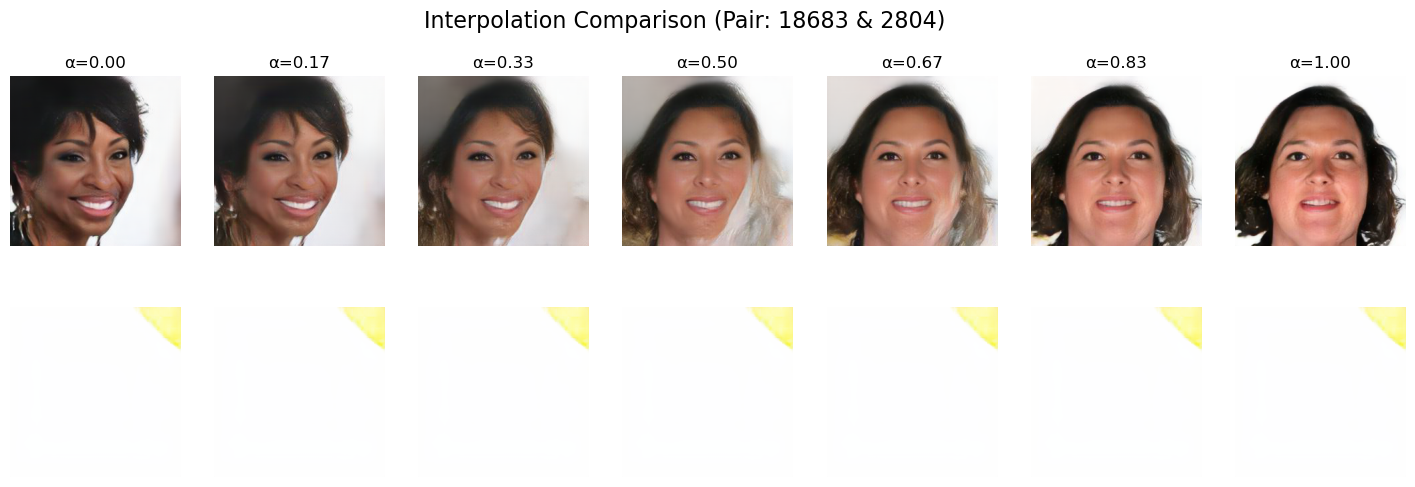


--- Test Pair #5 ---


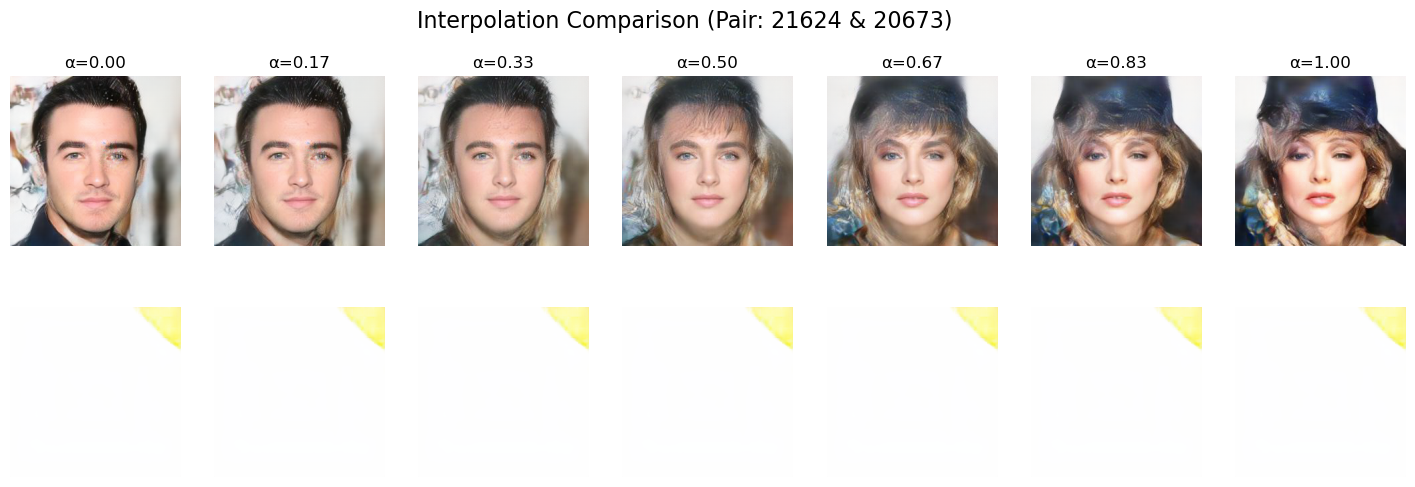

In [3]:
import os
import torch
import torch.nn as nn
import numpy as np
from PIL import Image
from torch.utils.data import Dataset
from torchvision import transforms
import matplotlib.pyplot as plt
import random

# --- 1. 모든 필요한 클래스 정의 ---
# (ResBlock, EncoderSuperDeep, DecoderSuperDeep, InterpolationNet, CustomImageDataset 클래스 정의)
# (이전 코드와 동일하므로 여기에 다시 붙여넣으시면 됩니다)
class ResBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(nn.Conv2d(in_channels, out_channels, 3, 1, 1), nn.BatchNorm2d(out_channels), nn.SiLU(), nn.Conv2d(out_channels, out_channels, 3, 1, 1), nn.BatchNorm2d(out_channels))
        self.shortcut = nn.Conv2d(in_channels, out_channels, 1) if in_channels != out_channels else nn.Identity()
        self.silu = nn.SiLU()
    def forward(self, x): return self.silu(self.block(x) + self.shortcut(x))
class EncoderSuperDeep(nn.Module):
    def __init__(self, in_channels=3, base_channels=128, latent_channels=1): # 원본 VAE는 128 기준
        super().__init__()
        self.encoder = nn.Sequential(nn.Conv2d(in_channels, base_channels, 3, 1, 1), ResBlock(base_channels, base_channels), nn.Conv2d(base_channels, base_channels*2, 3, 2, 1), ResBlock(base_channels*2, base_channels*2), nn.Conv2d(base_channels*2, base_channels*4, 3, 2, 1), ResBlock(base_channels*4, base_channels*4), nn.Conv2d(base_channels*4, base_channels*8, 3, 2, 1), ResBlock(base_channels*8, base_channels*8), nn.Conv2d(base_channels*8, base_channels*16, 3, 2, 1), ResBlock(base_channels*16, base_channels*16), nn.Conv2d(base_channels*16, 2 * latent_channels, 3, 1, 1))
    def forward(self, x):
        x = self.encoder(x)
        mu, log_var = torch.chunk(x, 2, dim=1)
        return mu, log_var
class DecoderSuperDeep(nn.Module):
    def __init__(self, out_channels=3, base_channels=128, latent_channels=1): # 원본 VAE는 128 기준
        super().__init__()
        self.decoder = nn.Sequential(nn.Conv2d(latent_channels, base_channels*16, 3, 1, 1), ResBlock(base_channels*16, base_channels*16), nn.Upsample(scale_factor=2, mode='nearest'), nn.Conv2d(base_channels*16, base_channels*8, 3, 1, 1), ResBlock(base_channels*8, base_channels*8), nn.Upsample(scale_factor=2, mode='nearest'), nn.Conv2d(base_channels*8, base_channels*4, 3, 1, 1), ResBlock(base_channels*4, base_channels*4), nn.Upsample(scale_factor=2, mode='nearest'), nn.Conv2d(base_channels*4, base_channels*2, 3, 1, 1), ResBlock(base_channels*2, base_channels*2), nn.Upsample(scale_factor=2, mode='nearest'), nn.Conv2d(base_channels*2, base_channels, 3, 1, 1), ResBlock(base_channels, base_channels), nn.Conv2d(base_channels, out_channels, 3, 1, 1), nn.Tanh())
    def forward(self, z): return self.decoder(z)
class InterpolationNet(nn.Module):
    def __init__(self, latent_dim=256, hidden_dim=1024):
        super().__init__()
        input_dim = latent_dim * 2 + 1
        self.network = nn.Sequential(nn.Linear(input_dim, hidden_dim), nn.BatchNorm1d(hidden_dim), nn.LeakyReLU(0.2, inplace=True), nn.Linear(hidden_dim, hidden_dim), nn.BatchNorm1d(hidden_dim), nn.LeakyReLU(0.2, inplace=True), nn.Linear(hidden_dim, hidden_dim // 2), nn.BatchNorm1d(hidden_dim // 2), nn.LeakyReLU(0.2, inplace=True), nn.Linear(hidden_dim // 2, latent_dim))
    def forward(self, z_a, z_b, alpha):
        net_input = torch.cat([z_a, z_b, alpha], dim=1)
        return self.network(net_input)
class CustomImageDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.paths = sorted([os.path.join(root_dir, f) for f in os.listdir(root_dir) if f.lower().endswith(('.jpg','.jpeg','.png'))])
        self.transform = transform
    def __len__(self): return len(self.paths)
    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert('RGB')
        if self.transform: img = self.transform(img)
        return img, idx
def denormalize(tensor):
    return (tensor.clamp(-1, 1) * 0.5) + 0.5


def test_interpolation_network(num_tests=5):
    # --- 2. 경로 설정 및 모델 로드 ---
    DEVICE = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")
    
    AE_CHECKPOINT_DIR = '/home/nas/data/YMG/superdeep_ae/checkpoints/'
    ENCODER_PATH = os.path.join(AE_CHECKPOINT_DIR, 'encoder_superdeep_best.pth')
    DECODER_PATH = os.path.join(AE_CHECKPOINT_DIR, 'decoder_superdeep_best.pth')
    DATA_DIR = '/home/nas/data/YMG/datas/celeba_hq_256/'
    
    # **여기에 새로 학습된 보간 네트워크 체크포인트 경로를 정확히 입력하세요**
    INTERPOLATION_NET_DIR = '/home/nas/data/YMG/superdeep_ae/light_interpolation_network/'
    INTERPOLATION_NET_PATH = os.path.join(INTERPOLATION_NET_DIR, 'interpolation_net_best.pth')

    # 모든 모델 로드
    encoder = EncoderSuperDeep(base_channels=128).to(DEVICE); encoder.eval()
    decoder = DecoderSuperDeep(base_channels=128).to(DEVICE); decoder.eval()
    interpolation_net = InterpolationNet().to(DEVICE); interpolation_net.eval()

    encoder.load_state_dict(torch.load(ENCODER_PATH, map_location=DEVICE))
    decoder.load_state_dict(torch.load(DECODER_PATH, map_location=DEVICE))
    interpolation_net.load_state_dict(torch.load(INTERPOLATION_NET_PATH, map_location=DEVICE))
    print("모든 모델(VAE, 보간 네트워크)을 성공적으로 로드했습니다.")
    
    # 데이터셋 로드
    transform = transforms.Compose([transforms.Resize((256, 256)), transforms.ToTensor(), transforms.Normalize(mean=[0.5], std=[0.5])])
    dataset = CustomImageDataset(DATA_DIR, transform)
    
    # --- 3. 비교 테스트 수행 ---
    for i in range(num_tests):
        print(f"\n--- Test Pair #{i+1} ---")
        start_idx, end_idx = random.sample(range(len(dataset)), 2)
        num_steps = 7
        alphas = torch.linspace(0, 1, num_steps)

        # 원본 이미지 및 잠재 벡터 준비
        img_a_orig, _ = dataset[start_idx]
        img_b_orig, _ = dataset[end_idx]
        with torch.no_grad():
            mu_a, _ = encoder(img_a_orig.unsqueeze(0).to(DEVICE))
            mu_b, _ = encoder(img_b_orig.unsqueeze(0).to(DEVICE))
        
        # 보간 수행 (선형 vs 네트워크)
        lerp_latents = torch.cat([(1 - alpha) * mu_a + alpha * mu_b for alpha in alphas], dim=0)
        
        network_latents = []
        with torch.no_grad():
            for alpha in alphas:
                mu_a_flat = mu_a.view(1, -1)
                mu_b_flat = mu_b.view(1, -1)
                alpha_tensor = torch.tensor([[alpha]], device=DEVICE)
                inter_latent_flat = interpolation_net(mu_a_flat, mu_b_flat, alpha_tensor)
                network_latents.append(inter_latent_flat.view(1, 1, 16, 16))
        network_latents = torch.cat(network_latents, dim=0)

        # 이미지 생성
        with torch.no_grad():
            lerp_images = decoder(lerp_latents).cpu()
            network_images = decoder(network_latents).cpu()

        # 시각화
        fig, axes = plt.subplots(2, num_steps, figsize=(18, 5.5))
        fig.suptitle(f"Interpolation Comparison (Pair: {start_idx} & {end_idx})", fontsize=16)
        axes[0, 0].set_ylabel("Linear (Lerp)", fontsize=12)
        axes[1, 0].set_ylabel("Network ($I_\\theta$)", fontsize=12)

        for j in range(num_steps):
            axes[0, j].imshow(denormalize(lerp_images[j]).permute(1, 2, 0)); axes[0, j].axis('off')
            axes[1, j].imshow(denormalize(network_images[j]).permute(1, 2, 0)); axes[1, j].axis('off')
            axes[0, j].set_title(f"α={alphas[j]:.2f}")
        plt.show()

if __name__ == '__main__':
    test_interpolation_network()